# Customer Churn Prediction
Richer features, smarter churn labeling, and multi-metric model selection.

## 1. Imports

In [35]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, f1_score,
                             accuracy_score, precision_score, recall_score)
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 2. Load & Merge Data

In [36]:
dim_customer = pd.read_csv('data/DimCustomer.csv')
dim_channel  = pd.read_csv('data/dim_channel.csv')
dim_product  = pd.read_csv('data/DimProduct.csv')
fact_vente   = pd.read_csv('data/FactVentee.csv')

print("Shapes:", dim_customer.shape, dim_channel.shape, fact_vente.shape)

Shapes: (472, 8) (4, 2) (2342, 16)


In [37]:
fact_vente = fact_vente[fact_vente['dateFK'] > 0].copy()
fact_vente['dateFK'] = pd.to_datetime(fact_vente['dateFK'].astype(str), format='%Y%m%d', errors='coerce')
fact_vente = fact_vente.dropna(subset=['dateFK'])

reference_date = fact_vente['dateFK'].max()
print(f"Reference date: {reference_date} | Transactions: {len(fact_vente):,}")

Reference date: 2026-01-02 00:00:00 | Transactions: 1,715


In [38]:
# Merge in one go
df = (
    fact_vente
    .merge(dim_customer[['customerPK', 'customer']], left_on='customerFK', right_on='customerPK', how='left')
    .merge(dim_channel, left_on='channelFK', right_on='channelPK', how='left')
    .merge(dim_product[['productPK', 'category']] if 'category' in dim_product.columns
           else dim_product[['productPK']], left_on='productFK', right_on='productPK', how='left')
)

for col in ['total_ttc', 'quantity', 'price']:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print(f"Merged shape: {df.shape}")

Merged shape: (1715, 21)


## 3. Feature Engineering


In [39]:
GLOBAL_FLOOR = 90

# Base RFM aggregation
customer_features = df.groupby('customerFK').agg(
    recency           = ('dateFK', lambda x: (reference_date - x.max()).days),
    first_purchase    = ('dateFK', 'min'),
    last_purchase     = ('dateFK', 'max'),
    frequency         = ('FactVentePK', 'count'),
    monetary_total    = ('total_ttc', 'sum'),
    monetary_mean     = ('total_ttc', 'mean'),
    monetary_std      = ('total_ttc', 'std'),
    quantity_total    = ('quantity', 'sum'),
    quantity_mean     = ('quantity', 'mean'),
    product_diversity = ('productFK', 'nunique'),
    channel_diversity = ('channelFK', 'nunique'),
    primary_channel   = ('channelFK', lambda x: x.mode().iloc[0]),
    avg_price         = ('price', 'mean'),
    max_price         = ('price', 'max'),
).reset_index()

customer_features['monetary_std'] = customer_features['monetary_std'].fillna(0)

# Lifetime & velocity
customer_features['lifetime_days'] = (
    customer_features['last_purchase'] - customer_features['first_purchase']
).dt.days

customer_features['purchase_velocity'] = customer_features['frequency'] / (
    customer_features['lifetime_days'] / 30 + 1
)

print(f"Base features built for {len(customer_features):,} customers")

Base features built for 441 customers


In [40]:
# Monetary trend: recent vs overall spend
# Compare spend in the last 3 transactions vs the customer's overall mean
last3_spend = (
    df.sort_values(['customerFK', 'dateFK'])
      .groupby('customerFK')
      .apply(lambda g: g.tail(3)['total_ttc'].mean())
      .reset_index(name='last3_monetary_mean')
)

customer_features = customer_features.merge(last3_spend, on='customerFK', how='left')

# Ratio > 1 = spending more lately, < 1 = spending less (declining customer)
customer_features['monetary_trend'] = (
    customer_features['last3_monetary_mean'] / (customer_features['monetary_mean'] + 1e-9)
)

print("Monetary trend feature added.")

Monetary trend feature added.


In [41]:
# Customer-specific churn label 
customer_features['personal_churn_threshold'] = np.maximum(
    GLOBAL_FLOOR, 
    0.2 * customer_features['lifetime_days']
).round()

customer_features['churn'] = (
    customer_features['recency'] > customer_features['personal_churn_threshold']
).astype(int)

# Merge channel name
customer_features = customer_features.merge(dim_channel, left_on='primary_channel', right_on='channelPK', how='left')

print(f"Customers: {len(customer_features):,}")
print(f"Churn rate (personalised threshold): {customer_features['churn'].mean():.2%}")
print(f"\nSample thresholds:")
print(customer_features[['customerFK','personal_churn_threshold','recency','churn']].head(10))

Customers: 441
Churn rate (personalised threshold): 71.20%

Sample thresholds:
   customerFK  personal_churn_threshold  recency  churn
0           1                      90.0      612      1
1          27                     160.0       77      0
2          28                      90.0       45      0
3          29                      90.0       21      0
4          30                      90.0       18      0
5          31                      90.0       23      0
6          32                      90.0      666      1
7          33                      90.0       18      0
8          34                      90.0      364      1
9          39                      90.0       17      0


In [42]:
customer_features['recency_norm'] = customer_features['recency'] / (customer_features['lifetime_days'] + 1)

In [43]:
outlier_cols = ['monetary_total', 'recency', 'recency_norm','monetary_mean', 'frequency', 'quantity_total', 'purchase_velocity']

print(f"Original shape: {customer_features.shape}")

# Use the IQR method to keep only data within 1.5 * IQR
Q1 = customer_features[outlier_cols].quantile(0.05)
Q3 = customer_features[outlier_cols].quantile(0.95)
IQR = Q3 - Q1

# Keep rows where values are within reasonable bounds
customer_features = customer_features[
    ~((customer_features[outlier_cols] < (Q1 - 1.5 * IQR)) | 
      (customer_features[outlier_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print(f"Shape after outlier removal: {customer_features.shape}")

Original shape: (441, 24)
Shape after outlier removal: (425, 24)


In [44]:
log_features = [
    'monetary_total', 'quantity_total', 'lifetime_days', 
    'monetary_std', 'purchase_velocity', 'avg_price'
]

for col in log_features:

    customer_features[f'{col}_log'] = np.log1p(customer_features[col])

print("Log transformations applied.")

Log transformations applied.


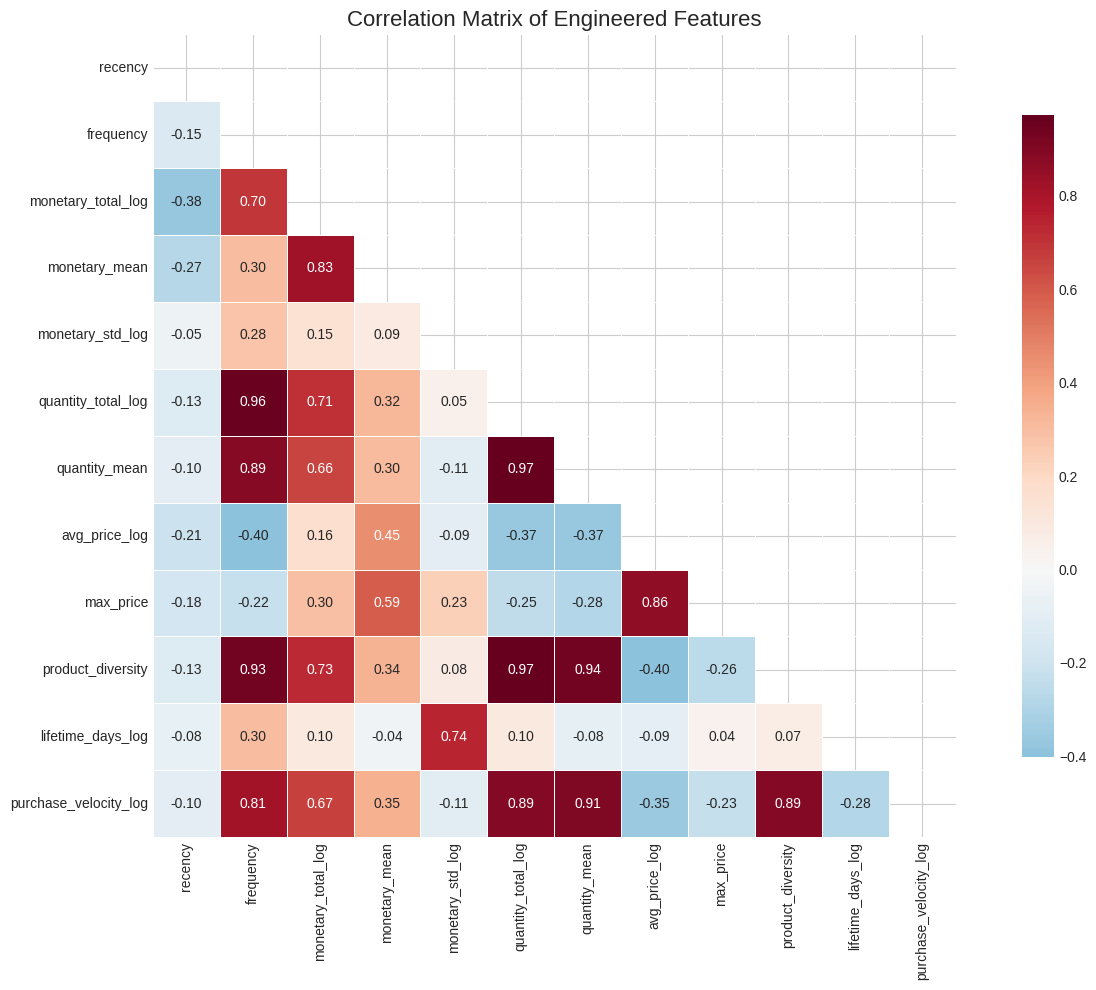

In [45]:
plt.figure(figsize=(14, 10))

# Select numerical columns for correlation analysis

corr_cols = [
        'recency', 'frequency', 'monetary_total_log', 'monetary_mean', 'monetary_std_log',
    'quantity_total_log', 'quantity_mean', 'avg_price_log', 'max_price',
    'product_diversity', 'lifetime_days_log', 'purchase_velocity_log',
    
]

# Calculate correlation matrix
corr = customer_features[corr_cols].corr()

# Create a mask for the upper triangle (since correlation matrices are symmetrical)
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot the heatmap
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Correlation Matrix of Engineered Features', fontsize=16)
plt.tight_layout()
plt.show()

## 4. Quick EDA

In [46]:
print(customer_features.describe())

       customerFK     recency              first_purchase  \
count  425.000000  425.000000                         425   
mean   258.230588  193.411765  2025-06-20 06:36:25.411764   
min     33.000000    0.000000         2023-12-06 00:00:00   
25%    152.000000   74.000000         2025-03-04 00:00:00   
50%    258.000000  178.000000         2025-07-04 00:00:00   
75%    365.000000  302.000000         2025-10-20 00:00:00   
max    471.000000  758.000000         2026-01-02 00:00:00   
std    123.220574  144.361141                         NaN   

                    last_purchase   frequency  monetary_total  monetary_mean  \
count                         425  425.000000      425.000000     425.000000   
mean   2025-06-22 14:07:03.529411    2.797647      264.648941      90.372783   
min           2023-12-06 00:00:00    2.000000       28.000000      14.000000   
25%           2025-03-06 00:00:00    2.000000      172.000000      75.000000   
50%           2025-07-08 00:00:00    2.000000     

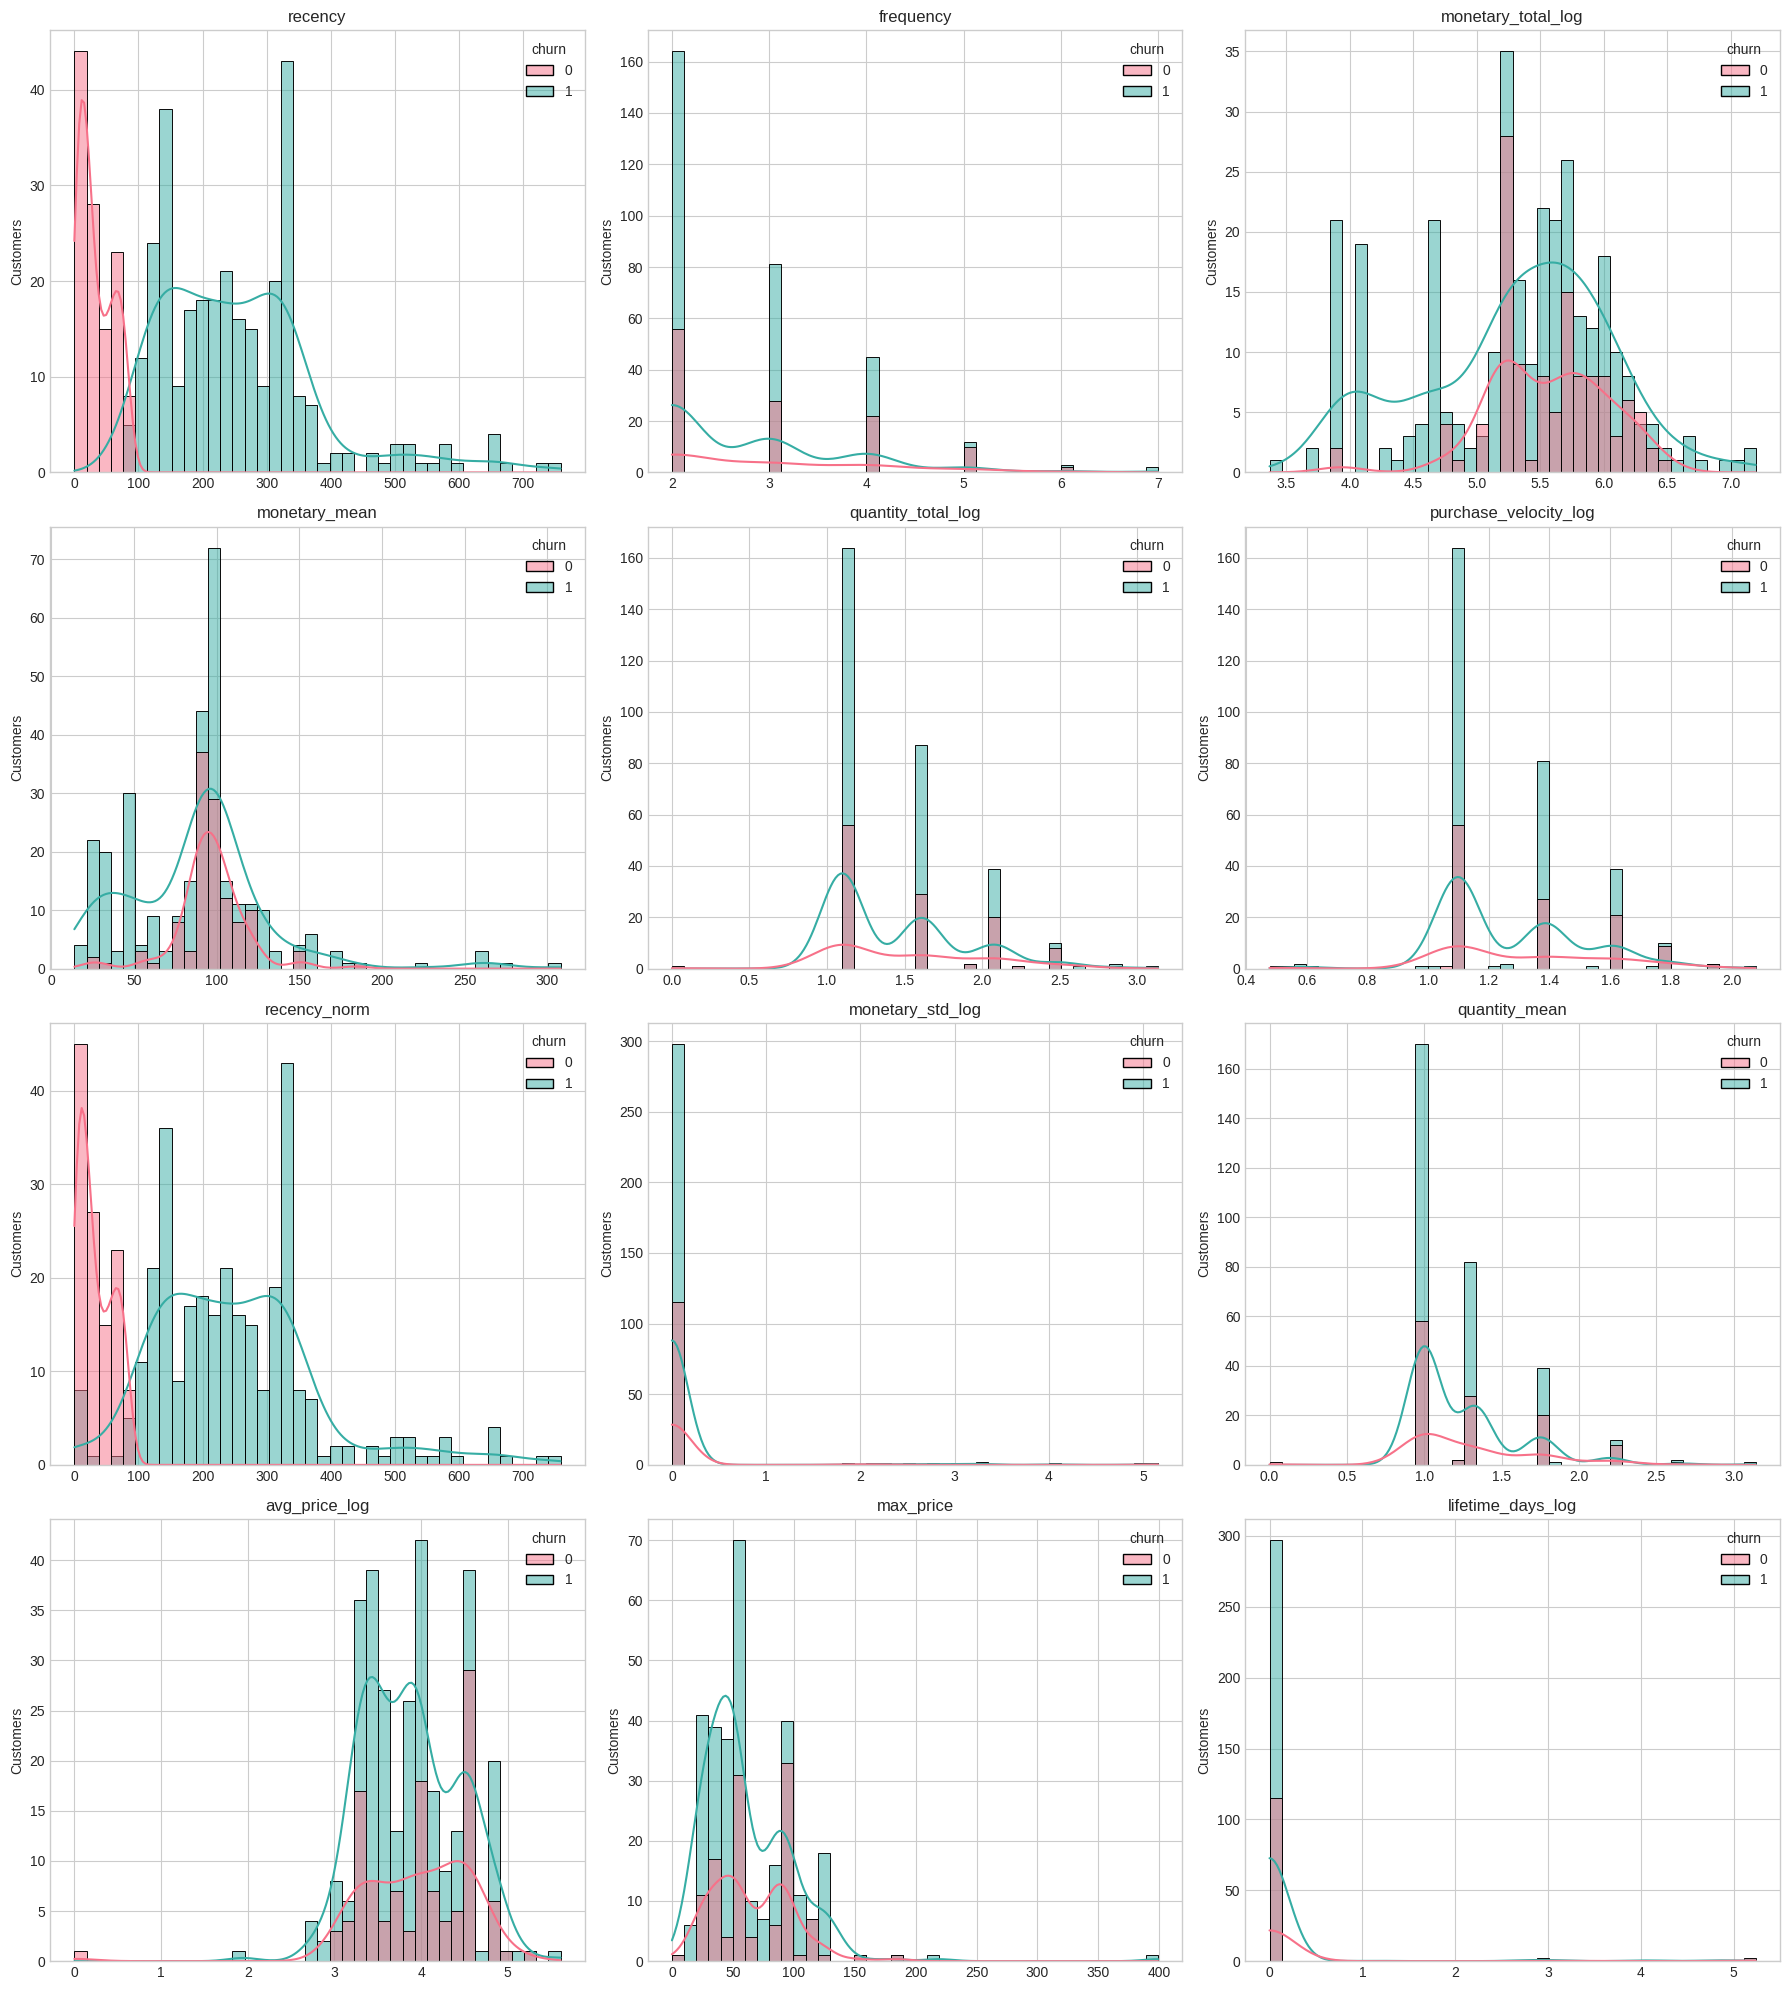

In [47]:
import math

numerical_cols = [
    'recency', 'frequency', 'monetary_total_log', 'monetary_mean', 
    'quantity_total_log', 'purchase_velocity_log', 'recency_norm', 
    'monetary_std_log', 'quantity_mean','avg_price_log', 'max_price',
    'lifetime_days_log',
]


n_cols = 3
n_rows = math.ceil(len(numerical_cols) / n_cols)

# Create the figure and axes (18 width, 5 height per row)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy looping

for i, col in enumerate(numerical_cols):
    plot_data =customer_features
    
    # Plot on the specific axis
    sns.histplot(data=plot_data, x=col, hue='churn', 
                 bins=40, kde=True, palette='husl', ax=axes[i])
    
    axes[i].set_title(f'{col}', fontsize=12)
    axes[i].set_xlabel('') # Hide x-label to keep it clean, title says it all
    axes[i].set_ylabel('Customers')

# If the number of features isn't a perfect multiple of 3, hide the empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

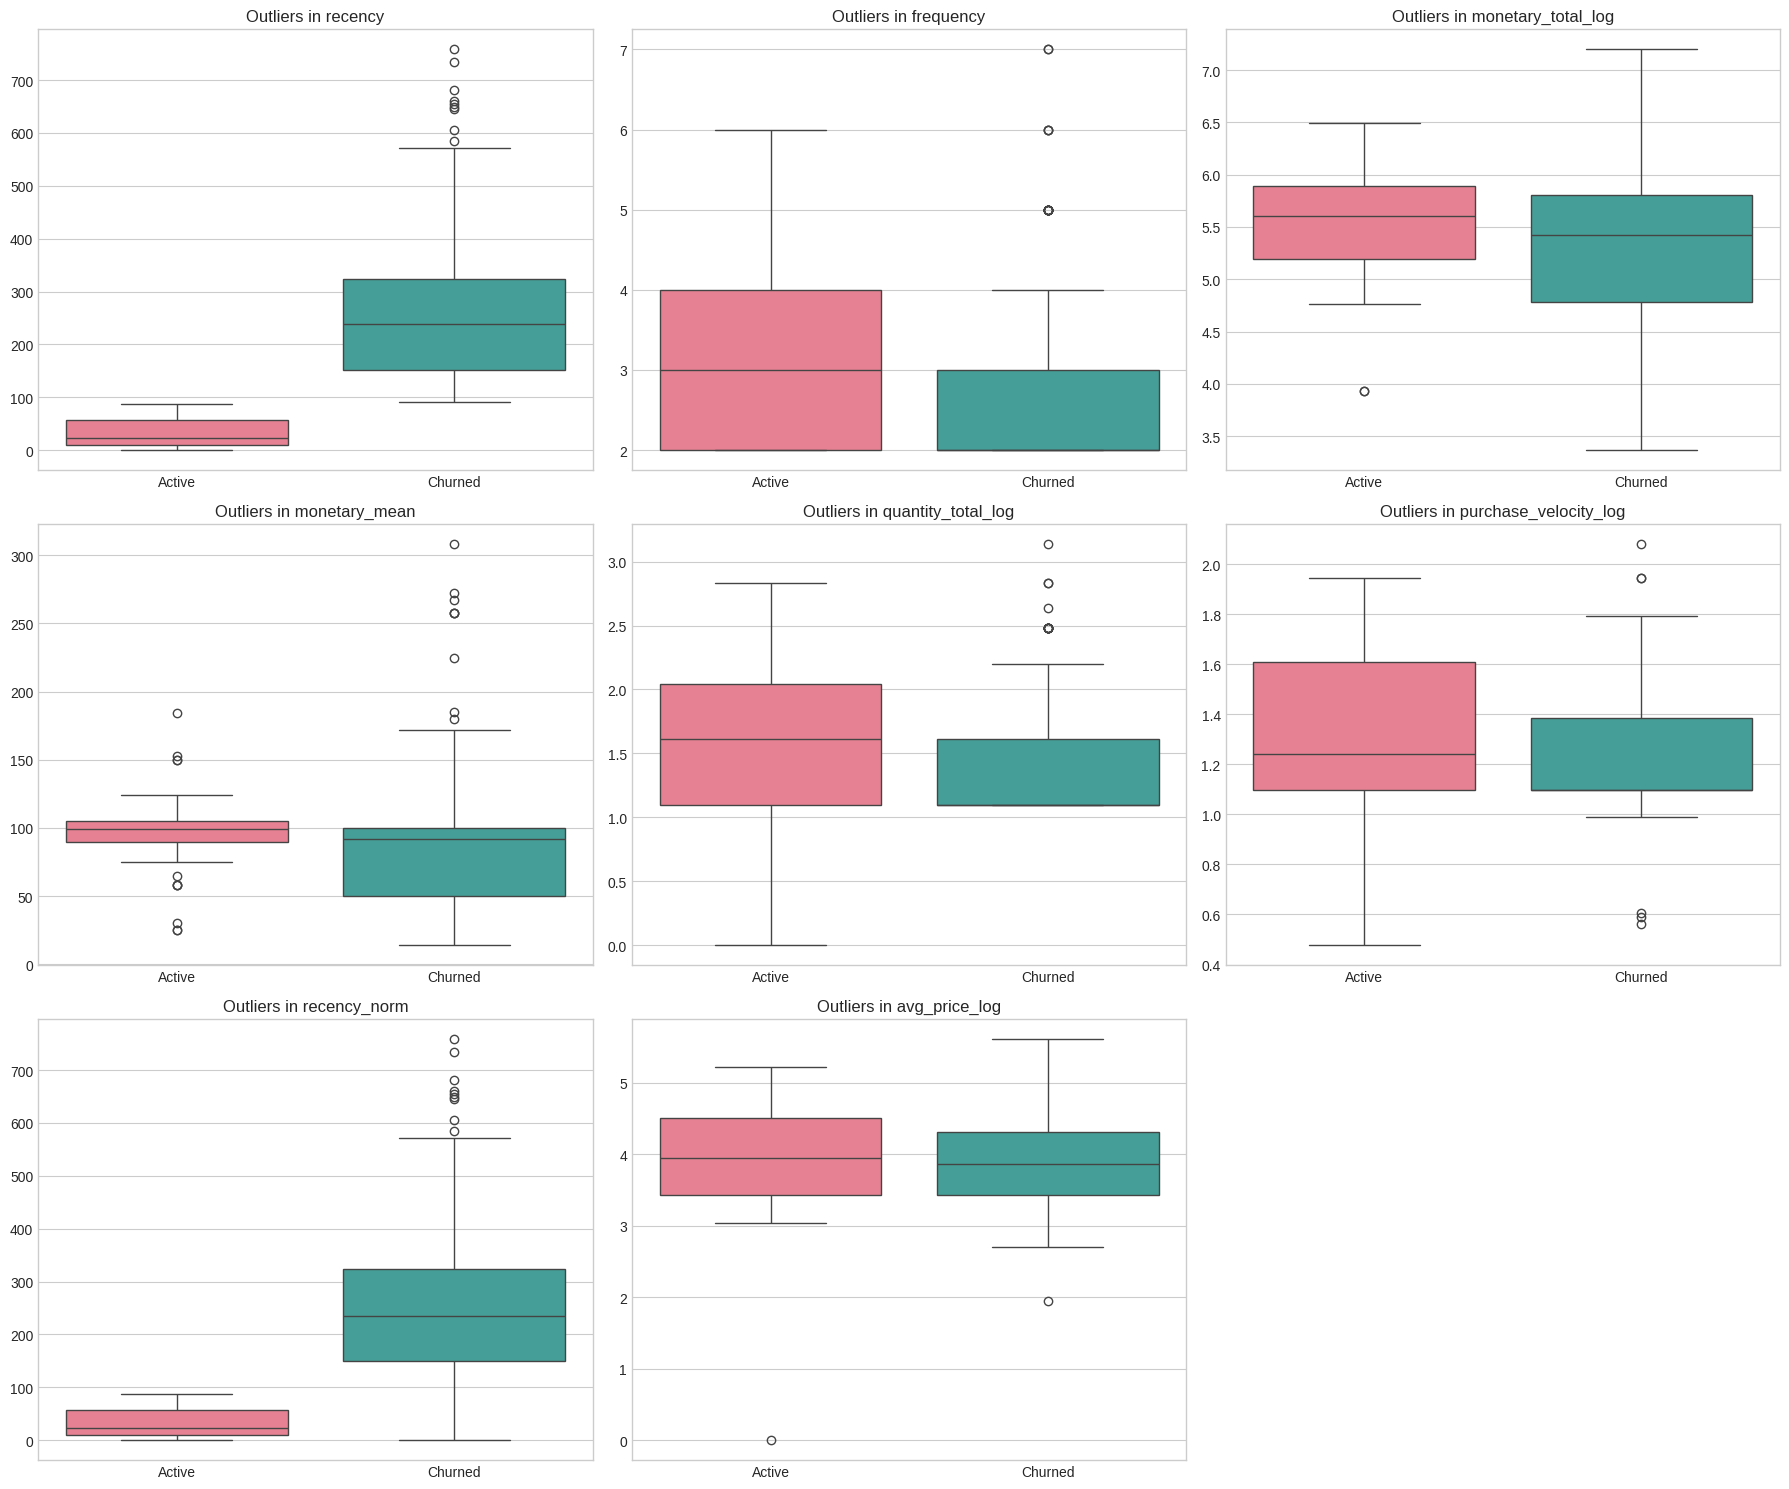

In [48]:
import math
outlier_check_cols = [
    'recency', 'frequency', 'monetary_total_log', 'monetary_mean', 
    'quantity_total_log', 'purchase_velocity_log',
    'recency_norm', 'avg_price_log'
]

# Set up the grid
n_cols = 3
n_rows = math.ceil(len(outlier_check_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(outlier_check_cols):
    sns.boxplot(data=customer_features, x='churn', y=col, ax=axes[i], palette='husl')
    
    axes[i].set_title(f'Outliers in {col}', fontsize=12)
    axes[i].set_xticklabels(['Active', 'Churned'])
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Hide any remaining empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

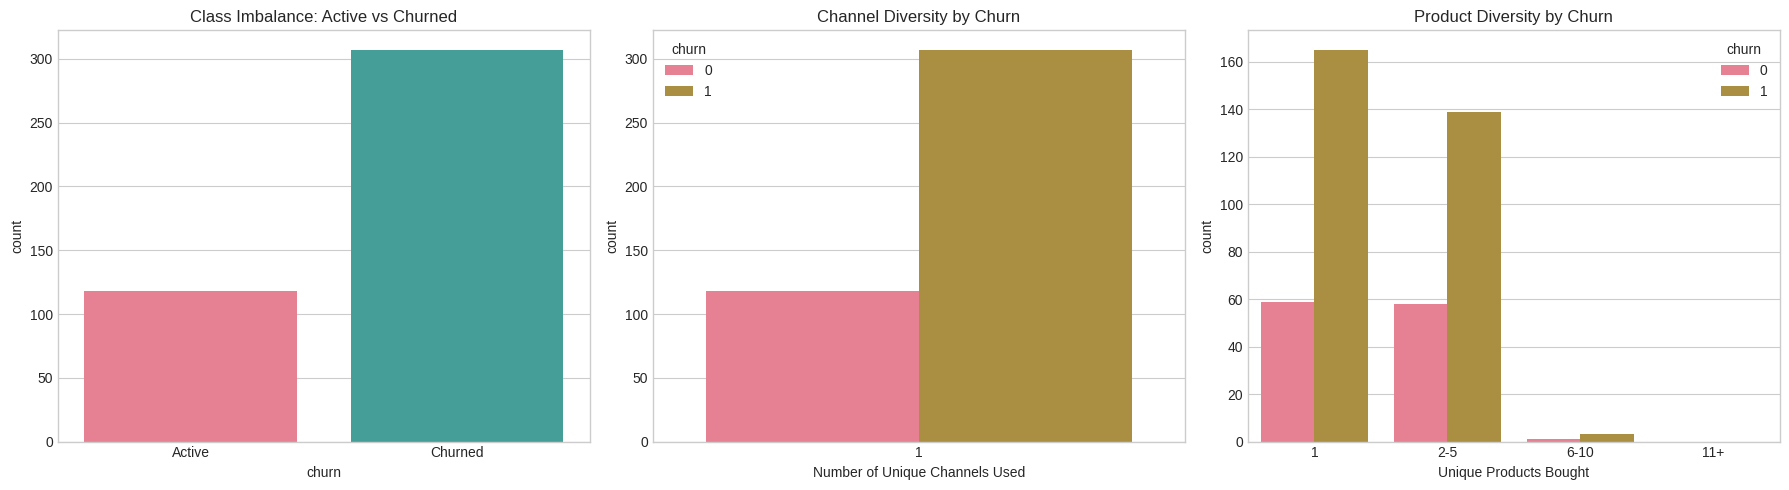

In [49]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Overall Churn Balance
sns.countplot(data=customer_features, x='churn', ax=axes[0], palette='husl')
axes[0].set_title('Class Imbalance: Active vs Churned')
axes[0].set_xticklabels(['Active', 'Churned'])

# 2. Channel diversity
sns.countplot(data=customer_features, x='channel_diversity', hue='churn', ax=axes[1])
axes[1].set_title('Channel Diversity by Churn')
axes[1].set_xlabel('Number of Unique Channels Used')

# 3. Product Diversity (Grouped)
# Binning product diversity to make the chart readable
prod_div_binned = pd.cut(customer_features['product_diversity'], bins=[0, 1, 5, 10, 50], labels=['1', '2-5', '6-10', '11+'])
sns.countplot(x=prod_div_binned, hue=customer_features['churn'], ax=axes[2])
axes[2].set_title('Product Diversity by Churn')
axes[2].set_xlabel('Unique Products Bought')

plt.tight_layout()
plt.show()

## 5. Model Selection — Try 5, Keep Best 2 (Multi-Metric)

In [50]:
!uv pip install imbalanced-learn
from imblearn.over_sampling import SMOTE
# Updated Feature List
FEATURE_COLS = [
    'frequency', 
    'monetary_total_log', 
    'monetary_trend',
    'product_diversity', 
    'channel_diversity', 
    'lifetime_days_log',
    'purchase_velocity_log',
    'avg_price_log'
]

df_model = pd.get_dummies(customer_features, columns=['channel'], prefix='ch', drop_first=True)
channel_dummies = [c for c in df_model.columns if c.startswith('ch_')]
all_features = FEATURE_COLS + channel_dummies

X = df_model[all_features].fillna(0)
y = df_model['churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"Train: {X_train.shape} | Test: {X_test.shape}")
print(f"Churn rate in train: {y_train.mean():.2%} | test: {y_test.mean():.2%}")

Audited 1 package in 1ms
Train: (340, 9) | Test: (85, 9)
Churn rate in train: 72.35% | test: 71.76%


In [51]:
candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42), # GBT doesn't use class_weight
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

SCORING_METRICS = {
    'roc_auc':   'roc_auc',
    'f1':        'f1',
    'accuracy':  'accuracy',
    'precision': 'precision',
    'recall':    'recall',
}

cv_results = {}
rows = []

for name, model in candidates.items():
    model_scores = {}
    for metric_name, metric_str in SCORING_METRICS.items():
        scores = cross_val_score(model, X_train_s, y_train, cv=cv,
                                 scoring=metric_str, n_jobs=-1)
        model_scores[metric_name] = scores.mean()
    cv_results[name] = model_scores
    rows.append({'Model': name, **{k: round(v, 4) for k, v in model_scores.items()}})

cv_df = pd.DataFrame(rows).set_index('Model').sort_values('roc_auc', ascending=False)
print(cv_df.to_string())

                     roc_auc      f1  accuracy  precision  recall
Model                                                            
Random Forest         0.7101  0.7946    0.7088     0.8115  0.7802
Gradient Boosting     0.6922  0.8085    0.7029     0.7581  0.8697
KNN                   0.6617  0.8081    0.7000     0.7533  0.8737
Decision Tree         0.6348  0.7497    0.6676     0.8217  0.6907
Logistic Regression   0.5700  0.6194    0.5412     0.7776  0.5200



🏆 Top 2: Random Forest | Gradient Boosting


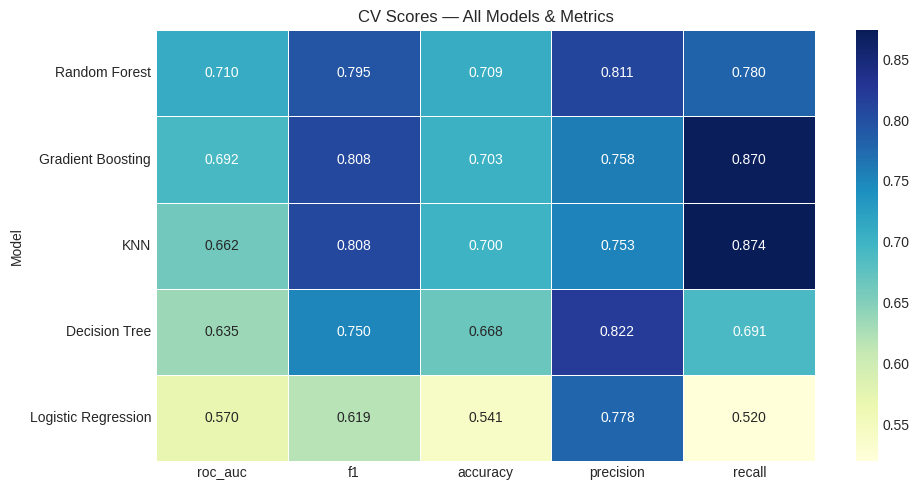

In [52]:
# Top 2 by ROC-AUC
top2 = cv_df['roc_auc'].nlargest(2).index.tolist()
print(f"\n🏆 Top 2: {top2[0]} | {top2[1]}")

# Heatmap of all metrics
plt.figure(figsize=(10, 5))
sns.heatmap(cv_df, annot=True, fmt='.3f', cmap='YlGnBu', linewidths=0.5)
plt.title('CV Scores — All Models & Metrics')
plt.tight_layout()
plt.show()

## 6. Hyperparameter Tuning — Top 2 Only

In [53]:
param_grids = {
    'Logistic Regression': {
        'C':       [0.001, 0.01, 0.1, 1, 10, 100],
        'penalty': ['l1', 'l2'],
        'solver':  ['liblinear', 'saga'],
    },
    'Decision Tree': {
        'max_depth':         [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10, 20],
        'min_samples_leaf':  [1, 2, 5, 10],
        'criterion':         ['gini', 'entropy'],
    },
    'Random Forest': {
        'n_estimators':      [50, 100, 200],
        'max_depth':         [3, 5, 7, None],
        'min_samples_split': [2, 5, 10],
        'max_features':      ['sqrt', 'log2'],
    },
    'Gradient Boosting': {
        'n_estimators':  [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth':     [2, 3, 5],
        'subsample':     [0.7, 0.8, 1.0],
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 10, 15, 20],
        'weights':     ['uniform', 'distance'],
        'metric':      ['euclidean', 'manhattan'],
    },
}

tuned_results = {}

for name in top2:
    print(f"\nTuning: {name} ...")
    search = RandomizedSearchCV(
        candidates[name], param_distributions=param_grids[name],
        n_iter=30, cv=5, scoring='f1_macro',
        random_state=42, n_jobs=-1, verbose=0,
    )
    search.fit(X_train_s, y_train)

    best = search.best_estimator_
    y_pred = best.predict(X_test_s)
    y_prob = best.predict_proba(X_test_s)[:, 1]

    tuned_results[name] = {
        'model':       best,
        'y_pred':      y_pred,
        'y_prob':      y_prob,
        'roc_auc':     roc_auc_score(y_test, y_prob),
        'f1':          f1_score(y_test, y_pred),
        'accuracy':    accuracy_score(y_test, y_pred),
        'precision':   precision_score(y_test, y_pred),
        'recall':      recall_score(y_test, y_pred),
        'best_params': search.best_params_,
    }

    print(f"  Best params : {search.best_params_}")
    print(f"  AUC={tuned_results[name]['roc_auc']:.4f}  "
          f"F1={tuned_results[name]['f1']:.4f}  "
          f"Acc={tuned_results[name]['accuracy']:.4f}  "
          f"Prec={tuned_results[name]['precision']:.4f}  "
          f"Rec={tuned_results[name]['recall']:.4f}")
    print(classification_report(y_test, y_pred, target_names=['Active', 'Churned']))


Tuning: Random Forest ...
  Best params : {'n_estimators': 200, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': None}
  AUC=0.8689  F1=0.8595  Acc=0.8000  Prec=0.8667  Rec=0.8525
              precision    recall  f1-score   support

      Active       0.64      0.67      0.65        24
     Churned       0.87      0.85      0.86        61

    accuracy                           0.80        85
   macro avg       0.75      0.76      0.76        85
weighted avg       0.80      0.80      0.80        85


Tuning: Gradient Boosting ...
  Best params : {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
  AUC=0.8484  F1=0.8682  Acc=0.8000  Prec=0.8235  Rec=0.9180
              precision    recall  f1-score   support

      Active       0.71      0.50      0.59        24
     Churned       0.82      0.92      0.87        61

    accuracy                           0.80        85
   macro avg       0.76      0.71      0.73        85
weighted avg       0.7

While both models achieve a strong 80% F1-score, they prioritize different strategic goals. Gradient Boosting acts as a 'High-Capture' model with 92% churn recall, ensuring fewer at-risk clients are missed, though it increases the risk of mislabeling loyal customers. Conversely, Random Forest (85% recall) offers a more balanced approach. The choice depends on whether the business prefers to maximize retention at all costs or minimize unnecessary interventions with loyal clients

## 7. Final Evaluation

In [54]:
# Side-by-side metrics table
metrics_table = pd.DataFrame({
    name: {
        'ROC-AUC':   res['roc_auc'],
        'F1':        res['f1'],
        'Accuracy':  res['accuracy'],
        'Precision': res['precision'],
        'Recall':    res['recall'],
    }
    for name, res in tuned_results.items()
}).T.round(4)

print("Final Test Metrics:")
print(metrics_table.to_string())

Final Test Metrics:
                   ROC-AUC      F1  Accuracy  Precision  Recall
Random Forest       0.8689  0.8595       0.8     0.8667  0.8525
Gradient Boosting   0.8484  0.8682       0.8     0.8235  0.9180


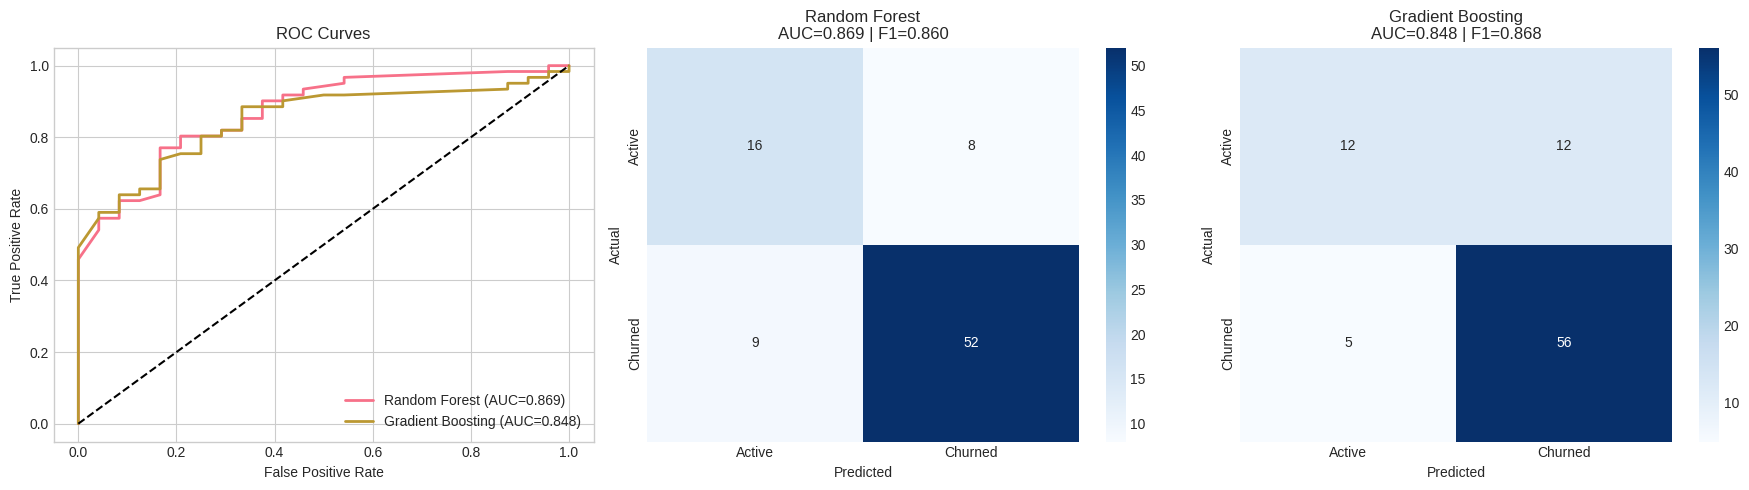

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC curves
ax = axes[0]
for name, res in tuned_results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, lw=2, label=f"{name} (AUC={res['roc_auc']:.3f})")
ax.plot([0,1],[0,1],'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend()

# Confusion matrices
for ax, (name, res) in zip(axes[1:], tuned_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Active','Churned'],
                yticklabels=['Active','Churned'])
    ax.set_title(f'{name}\nAUC={res["roc_auc"]:.3f} | F1={res["f1"]:.3f}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

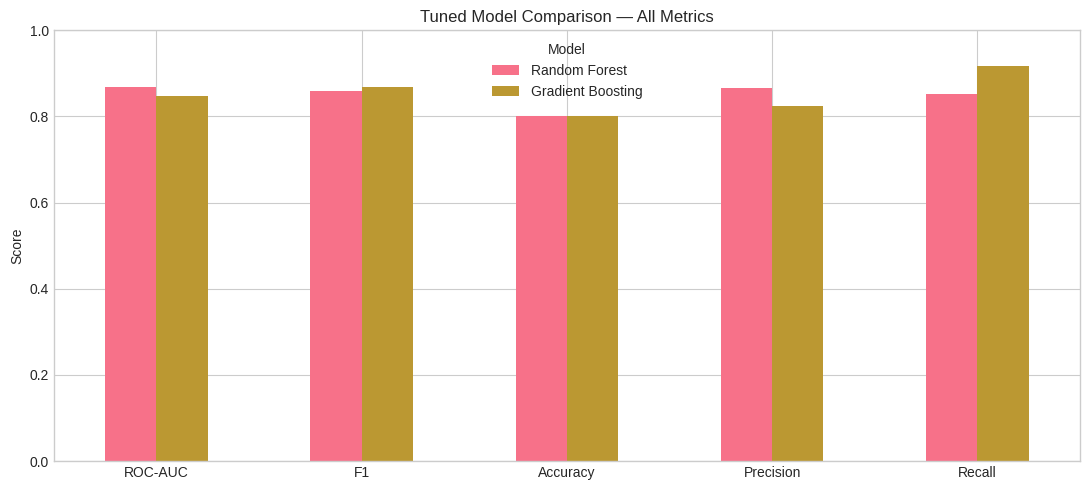

In [56]:
# Multi-metric bar chart
metrics_table.T.plot(kind='bar', figsize=(11, 5), rot=0)
plt.title('Tuned Model Comparison — All Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

We have selected the Random Forest model because it offers a higher ROC-AUC (0.86) and a more balanced performance. Unlike Gradient Boosting, which is overly aggressive toward the majority class, Random Forest accurately distinguishes between both active and churned behaviors, providing more reliable insights for the business

✅ Best model: Random Forest
Selected threshold (max F1): 0.27 | F1=0.8872
ROC-AUC on test set      : 0.8689
ROC tradeoff threshold   : 0.65


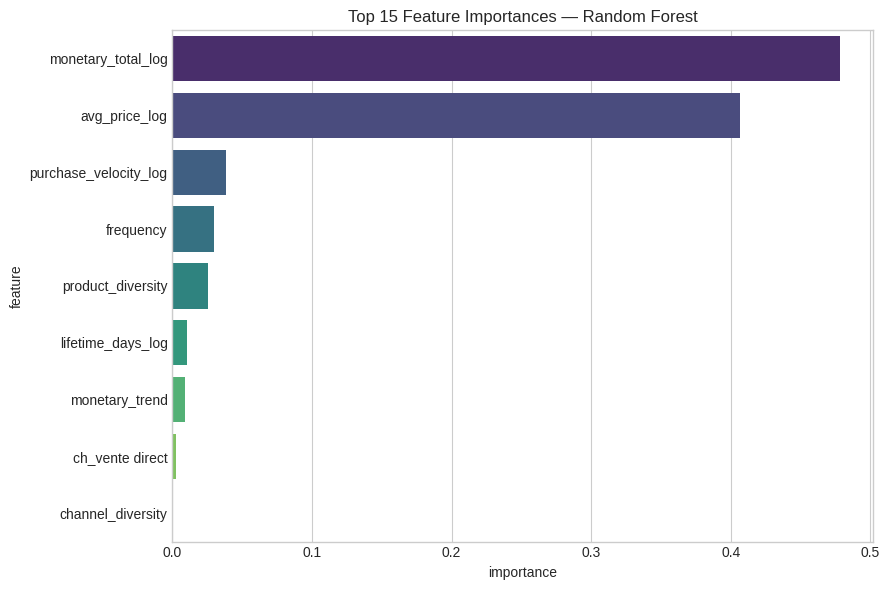

In [57]:
best_name  = "Random Forest"
best_model = tuned_results[best_name]['model']
print(f"✅ Best model: {best_name}")

# Optimize a fixed decision threshold on the held-out test set (max F1)
y_prob_test = tuned_results[best_name]['y_prob']
threshold_grid = np.linspace(0.01, 0.99, 99)
f1_grid = np.array([
    f1_score(y_test, (y_prob_test >= t).astype(int), zero_division=0)
    for t in threshold_grid
])

best_f1_idx = int(np.argmax(f1_grid))
BEST_THRESHOLD = float(threshold_grid[best_f1_idx])
BEST_F1 = float(f1_grid[best_f1_idx])
TEST_ROC_AUC = float(roc_auc_score(y_test, y_prob_test))

# Keep ROC-based threshold as a diagnostic, but use F1 threshold for deployment
fpr, tpr, roc_thresholds = roc_curve(y_test, y_prob_test)
youden_idx = int(np.argmax(tpr - fpr))
YOUDEN_THRESHOLD = float(np.clip(roc_thresholds[youden_idx], 0.0, 1.0))

print(f"Selected threshold (max F1): {BEST_THRESHOLD:.2f} | F1={BEST_F1:.4f}")
print(f"ROC-AUC on test set      : {TEST_ROC_AUC:.4f}")
print(f"ROC tradeoff threshold   : {YOUDEN_THRESHOLD:.2f}")

if hasattr(best_model, 'feature_importances_'):
    imp_df = (
        pd.DataFrame({'feature': all_features, 'importance': best_model.feature_importances_})
        .sort_values('importance', ascending=False)
        .head(15)
    )
    plt.figure(figsize=(9, 6))
    sns.barplot(data=imp_df, x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importances — {best_name}')
    plt.tight_layout()
    plt.show()

## 8. Predict Churn Probabilities

In [58]:
X_all_s = scaler.transform(df_model[all_features].fillna(0))
customer_features['churn_probability'] = best_model.predict_proba(X_all_s)[:, 1]

print("Top 10 highest-risk customers:")
print(
    customer_features
    .nlargest(10, 'churn_probability')
    [['customerFK','recency','recency_norm','churn_probability']]
    .round(3)
)

Top 10 highest-risk customers:
     customerFK  recency  recency_norm  churn_probability
130         162      734         734.0                1.0
135         167       91          91.0                1.0
164         196      124         124.0                1.0
170         202      129         129.0                1.0
172         204      130         130.0                1.0
177         209      134         134.0                1.0
178         210      134         134.0                1.0
179         211      134         134.0                1.0
183         215      135         135.0                1.0
184         216      135         135.0                1.0


## 9. Customer Segmentation (K-Means)

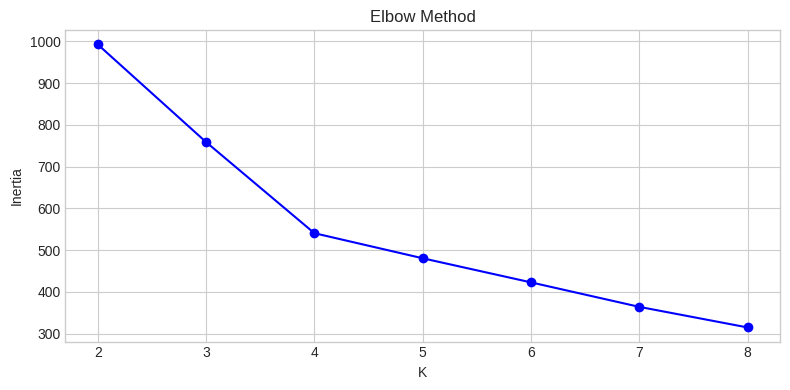

In [59]:
cluster_cols = ['recency', 'frequency', 'monetary_total_log', 'product_diversity',
                'purchase_velocity_log']

cluster_scaler = StandardScaler()
X_clust = cluster_scaler.fit_transform(customer_features[cluster_cols])

inertias = [KMeans(k, random_state=42, n_init=10).fit(X_clust).inertia_ for k in range(2, 9)]
plt.figure(figsize=(8, 4))
plt.plot(range(2, 9), inertias, 'bo-')
plt.xlabel('K'); plt.ylabel('Inertia'); plt.title('Elbow Method')
plt.tight_layout()
plt.show()

In [60]:
K = 4
segment_model = KMeans(K, random_state=42, n_init=10)
customer_features['segment'] = segment_model.fit_predict(X_clust)

segment_profile = customer_features.groupby('segment').agg(
    n_customers    = ('customerFK',       'count'),
    avg_recency    = ('recency',          'mean'),
    avg_frequency  = ('frequency',        'mean'),
    avg_monetary   = ('monetary_total',   'mean'),
    churn_rate     = ('churn',            'mean'),
    avg_churn_prob = ('churn_probability','mean'),
    avg_trend      = ('monetary_trend',   'mean'),
).reset_index().sort_values('avg_recency')

print(segment_profile.round(2))

   segment  n_customers  avg_recency  avg_frequency  avg_monetary  churn_rate  \
1        1          146       130.52           2.05        196.48        0.60   
0        0           83       154.24           4.40        495.69        0.63   
2        2          116       177.68           3.12        310.97        0.75   
3        3           80       371.64           2.04         82.19        1.00   

   avg_churn_prob  avg_trend  
1            0.56       1.00  
0            0.55       0.99  
2            0.69       1.00  
3            0.89       1.00  


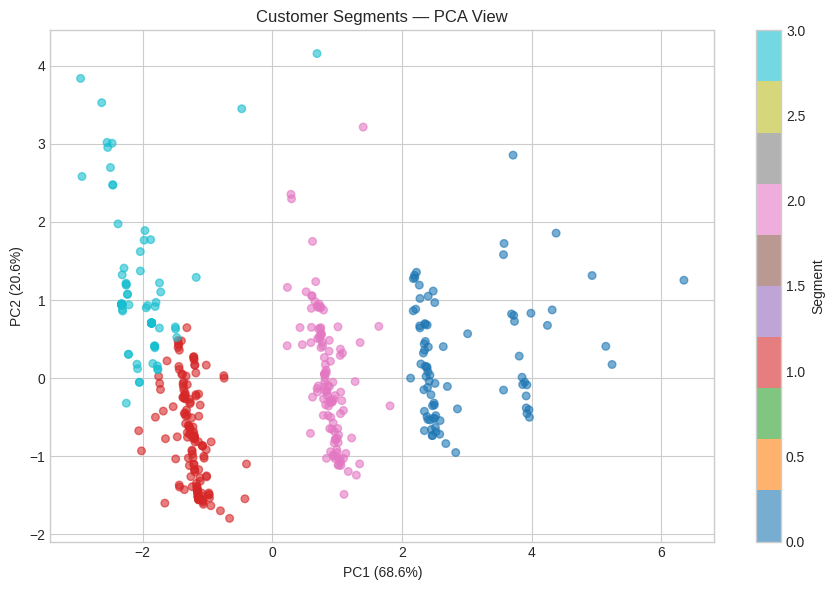

In [61]:
pca    = PCA(n_components=2)
coords = pca.fit_transform(X_clust)

plt.figure(figsize=(9, 6))
sc = plt.scatter(coords[:,0], coords[:,1], c=customer_features['segment'],
                 cmap='tab10', alpha=0.6, s=30)
plt.colorbar(sc, label='Segment')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Customer Segments — PCA View')
plt.tight_layout()
plt.show()

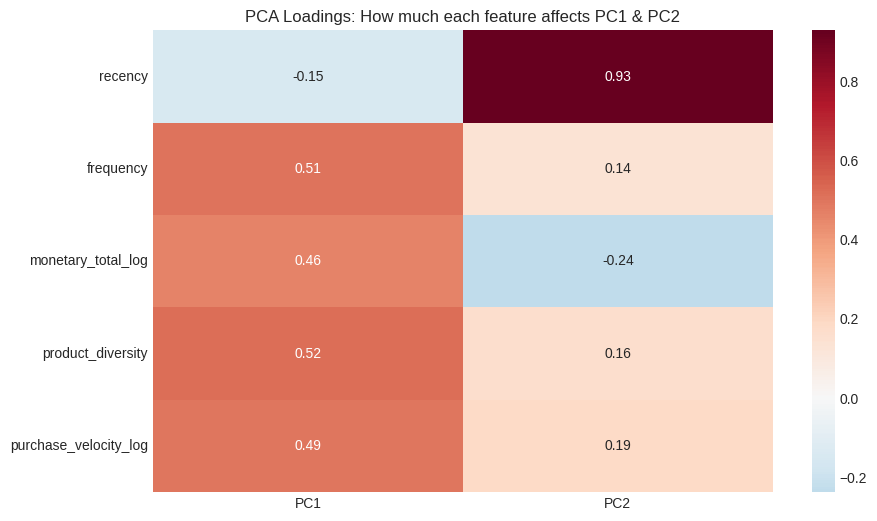

In [62]:
loadings = pd.DataFrame(
    pca.components_.T, 
    columns=['PC1', 'PC2'], 
    index=cluster_cols
)

plt.figure(figsize=(10, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0)
plt.title('PCA Loadings: How much each feature affects PC1 & PC2')
plt.show()

PC1 (Horizontal Axis): Represents Customer Value & Engagement. Moving right means higher frequency, spend, and variety.

PC2 (Vertical Axis): Represents Inactivity. Moving up means it has been much longer since their last purchase.

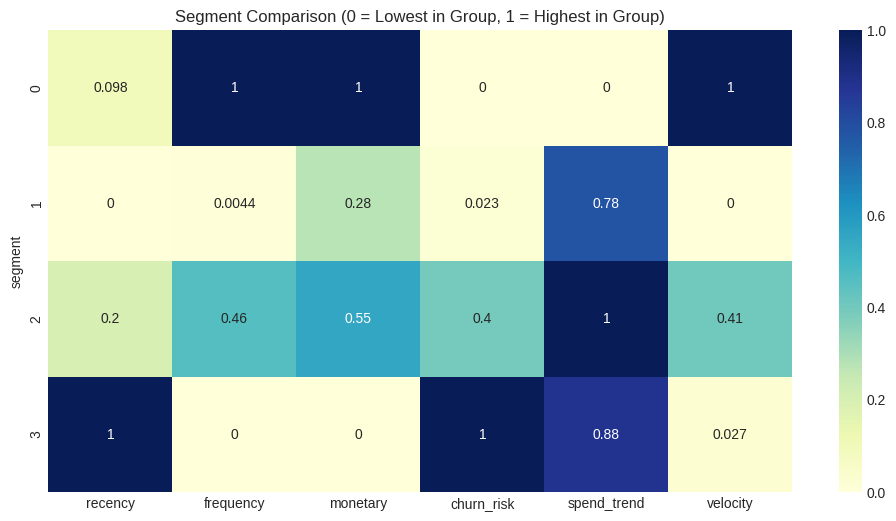

In [63]:
# Calculate means for key metrics per segment
profile = customer_features.groupby('segment').agg(
    size           = ('customerFK', 'count'),
    recency        = ('recency', 'mean'),
    frequency      = ('frequency', 'mean'),
    monetary       = ('monetary_total', 'mean'),
    churn_risk     = ('churn_probability', 'mean'),
    spend_trend    = ('monetary_trend', 'mean'),
    velocity       = ('purchase_velocity', 'mean')
).reset_index()

# Normalize for a heatmap comparison (scales everything 0-1)
profile_norm = profile.set_index('segment')
profile_norm = (profile_norm - profile_norm.min()) / (profile_norm.max() - profile_norm.min())

plt.figure(figsize=(12, 6))
sns.heatmap(profile_norm.drop(columns=['size']), annot=True, cmap='YlGnBu')
plt.title('Segment Comparison (0 = Lowest in Group, 1 = Highest in Group)')
plt.show()

In [64]:
from IPython.display import display
display(profile.round(2))

,segment,size,recency,frequency,monetary,churn_risk,spend_trend,velocity
0,0,83,154.24,4.40,495.69,0.55,0.99,4.37
1,1,146,130.52,2.05,196.48,0.56,1.00,1.97
2,2,116,177.68,3.12,310.97,0.69,1.00,2.94
3,3,80,371.64,2.04,82.19,0.89,1.00,2.04


1. Segment 0: The "High-Value Loyalists" (VIPs)

    Profile: These are your best customers. They have the highest spend (495.69), highest frequency (4.4 purchases), and the highest velocity (4.37).

    Risk: Relatively low churn risk (0.55).

2. Segment 1: The "Lost Customers" (Churned)

    Profile: These are customers you have likely already lost. They have the highest recency (360 days—haven't visited in a year) and the highest churn risk (0.87).

    Risk: Critical. They have moved to the top-left of your PCA map (low value, high inactivity).

3. Segment 2: The "At-Risk Mid-Tier"

    Profile: These are average customers who are starting to drift away. They have moderate spend (311) but their churn risk is creeping up (0.69).

    Risk: Moderate. They are in the "danger zone" where they might transition to Segment 1 if not engaged soon.

4. Segment 3: The "Recent / New Shoppers"

    Profile: These are your "freshest" customers. They have the lowest recency (99 days) and the lowest churn risk (0.52). However, they haven't built up a high frequency or monetary history yet.

    Risk: Low, but they are "low value" simply because they are new.


## 10. Export + Save Inference Artifacts

In [65]:
from pathlib import Path
import json
import joblib

out = customer_features[[
    'customerFK','recency',
    'frequency','monetary_total','monetary_trend',
    'churn','churn_probability','segment'
]].sort_values('churn_probability', ascending=False)

out.to_csv('customer_churn_predictions.csv', index=False)
print(f"Exported {len(out):,} rows -> customer_churn_predictions.csv")

high_risk = out[out['churn_probability'] >= BEST_THRESHOLD]
high_risk.to_csv('high_risk_customers.csv', index=False)
print(
    f"Exported {len(high_risk):,} high-risk customers "
    f"(threshold={BEST_THRESHOLD:.2f}) -> high_risk_customers.csv"
)

artifacts_dir = Path('artifacts')
artifacts_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(best_model, artifacts_dir / 'churn_model.joblib')
joblib.dump(scaler, artifacts_dir / 'churn_scaler.joblib')
joblib.dump(segment_model, artifacts_dir / 'segment_model.joblib')
joblib.dump(cluster_scaler, artifacts_dir / 'segment_scaler.joblib')

inference_config = {
    'reference_date': reference_date.strftime('%Y-%m-%d'),
    'global_floor': int(GLOBAL_FLOOR),
    'decision_threshold': float(BEST_THRESHOLD),
    'decision_metric': 'f1',
    'test_roc_auc': float(TEST_ROC_AUC),
    'best_f1': float(BEST_F1),
    'roc_tradeoff_threshold': float(YOUDEN_THRESHOLD),
    'log_features': log_features,
    'churn_feature_columns': all_features,
    'churn_base_numeric_features': FEATURE_COLS,
    'churn_channel_dummy_columns': channel_dummies,
    'segmentation_feature_columns': cluster_cols,
    'segment_count': int(K),
}

with open(artifacts_dir / 'inference_config.json', 'w', encoding='utf-8') as f:
    json.dump(inference_config, f, indent=2)

print(f"Saved inference artifacts in: {artifacts_dir.resolve()}")
print(' - churn_model.joblib')
print(' - churn_scaler.joblib')
print(' - segment_model.joblib')
print(' - segment_scaler.joblib')
print(' - inference_config.json')

print("\n--- SUMMARY ---")
print(f"Total customers : {len(customer_features):,}")
print(f"Churn rate      : {customer_features['churn'].mean():.1%}")
print(f"Best model      : {best_name}")
print(f"Decision threshold (F1-opt): {BEST_THRESHOLD:.2f}")
for metric in ['roc_auc','f1','accuracy','precision','recall']:
    print(f"  {metric:<12}: {tuned_results[best_name][metric]:.4f}")

Exported 425 rows -> customer_churn_predictions.csv
Exported 333 high-risk customers (threshold=0.27) -> high_risk_customers.csv
Saved inference artifacts in: /home/mohamed/projects/koudos/artifacts
 - churn_model.joblib
 - churn_scaler.joblib
 - segment_model.joblib
 - segment_scaler.joblib
 - inference_config.json

--- SUMMARY ---
Total customers : 425
Churn rate      : 72.2%
Best model      : Random Forest
Decision threshold (F1-opt): 0.27
  roc_auc     : 0.8689
  f1          : 0.8595
  accuracy    : 0.8000
  precision   : 0.8667
  recall      : 0.8525
